# Validating fkptjax's full $P_\ell$ against sMGPT's own reference (f(R), F5/BGS)

This notebook does the validation the two other notebooks in this repo
stopped short of: it computes the **final, fully RSD-projected**
$P_\ell(k)$ with `fkptjax` and compares it directly against
[sMGPT](https://github.com/alejandroaviles/sMGPT)'s own precomputed
reference for the exact same point -- their `outputs/plot_postprocessing.ipynb`,
"fkkernels" (fkPT-approximated) branch, for the `BGS_F5` configuration
(Hu-Sawicki f(R), $f_{R0}=-10^{-5}$, no screening).

**What's reused verbatim from sMGPT** (checked into
`examples/sMGPT_reference_data/`, from their repo at commit-time HEAD):
- `Abacus_pklin_z0.dat`: the exact linear $P(k)$ at $z=0$ they feed in.
- `AllFunctions_BGS_F5_fkkernels(.dat/_nw.dat)`: their Mathematica-computed
  kernel tables for the fkPT-approximated (`PTkernels=4`, screening off)
  branch.
- `compute_multipoles.py`: their own, unmodified Python post-processing
  module (`IRMultipolesModel`/`ParamsPost`) that turns those tables into
  final $P_\ell(k)$ multipoles -- run here exactly as in their notebook, with
  the same illustrative bias/EFT choice (`b1=2`, coevolution `b2`/`bs2`/`b3nl`,
  `alpha0=-10, alpha2=-50, alpha4=-30`, no shot noise).

**Exact match parameters**, read directly from sMGPT's
`0_input_F5_BGS.wl`/`outlogBGS_F5_fkkernels.txt`:
$\Omega_m=0.315192$, $z=0.295$ (their "BGS" tracer redshift), $f_{R0}=-10^{-5}$
("F5"), $\beta^2=1/6$, $n=1$, **screening off** (`Sc=0`, since `PTkernels=4`
is the *fkPT-approximated* branch -- their `PTkernels=1` "FullMG" branch
turns screening ON, which `fkptjax` does not implement at all, so that branch
is *not* a fair comparison target and is intentionally not used here).

**Growth-history convention.** sMGPT grows the $z=0$ input via the *true*
$f(R)$-modified growth ODE from $\eta_{\rm ini}$ (deep matter domination) all
the way to $z=0.295$, then divides by the same model's growth at a
small-$k$ pivot (effectively GR there) to calibrate the amplitude. To match
this using `fkptjax`'s existing `rescale_PS=True` machinery (which expects
the input $P(k)$ already at the *target* redshift under pure GR, then
multiplies by $(D_{\rm MG}/D_{\rm GR})^2$ evaluated at that redshift), this
notebook first GR-evolves the $z=0$ Abacus spectrum to $z=0.295$
(scale-independent, $\Omega_m=0.315192$) using `fkptjax.ode`'s own GR growth
solve, then hands that to `Kfuncs_to_tables`/`full_method_poles` with
`rescale_PS=True, beyond_eds=True, screening=0`. The two conventions are
mathematically equivalent whenever the small-$k$ pivot is close enough to GR
-- true here since f(R)'s modification is confined to small scales.


In [1]:
# Environment and path setup
import os
import sys
from pathlib import Path

os.environ.setdefault("FOLPS_BACKEND", "jax")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
for root in candidates:
    src = root / "src"
    if (src / "fkptjax").exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))
        print(f"Added to sys.path: {src}")
        break

DATA_DIR = cwd / "sMGPT_reference_data"
if not DATA_DIR.exists():
    DATA_DIR = cwd.parent / "examples" / "sMGPT_reference_data"
sys.path.insert(0, str(DATA_DIR))

print("cwd:", cwd)
print("DATA_DIR:", DATA_DIR)
print("python:", sys.executable)


cwd: /n/home12/cgarciaquintero/DESI/src/fkptjax_muMG/examples
DATA_DIR: /n/home12/cgarciaquintero/DESI/src/fkptjax_muMG/examples/sMGPT_reference_data
python: /n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/bin/python


In [2]:
# Imports
import time
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

from fkptjax.ode import ModelDerivatives, DP, ODESolver
from fkptjax.pipelines import full_method_poles
from fkptjax.rsd import pack_fkpt_bias

# sMGPT's own, unmodified post-processing module
from compute_multipoles import IRMultipolesModel, ParamsPost

print("JAX version:", jax.__version__)


JAX version: 0.9.1


## Step 1: reproduce sMGPT's own reference $P_\ell$

Run their `compute_multipoles.py` exactly as in `outputs/plot_postprocessing.ipynb`
against their precomputed `AllFunctions_BGS_F5_fkkernels(.dat/_nw.dat)`
tables. This is their *own* code and data -- no fkptjax involved yet.


In [3]:
b1 = 2
b2 = 8.0 / 21.0 * (b1 - 1.0)
bs2 = -4.0 / 7.0 * (b1 - 1.0)
b3nl = 32.0 / 315.0 * (b1 - 1.0)

model_smgpt = IRMultipolesModel(
    str(DATA_DIR / "AllFunctions_BGS_F5_fkkernels.dat"),
    str(DATA_DIR / "AllFunctions_BGS_F5_fkkernels_nw.dat"),
)
pars_smgpt = ParamsPost(
    b1=b1, b2=b2, bs2=bs2, b3nl=b3nl,
    alpha0=-10, alpha2=-50, alpha4=-30, ctilde=0.0,
    alphashot0=0.0, alphashot2=0.0, PshotP=0.0,
)
result_smgpt = model_smgpt.compute(pars_smgpt, ells=(0, 2, 4))
table_smgpt = np.asarray(result_smgpt["table"])

k_ref = table_smgpt[:, 0]
P0_ref, P2_ref, P4_ref = table_smgpt[:, 1], table_smgpt[:, 2], table_smgpt[:, 3]
print("sMGPT reference: k range", k_ref.min(), k_ref.max(), " npts:", len(k_ref))


sMGPT reference: k range 0.001 1.0  npts: 121


## Step 2: the same point through `fkptjax`

Same cosmology, same $z$, same $f_{R0}$, same bias/EFT parameters, same
(exact) input linear spectrum -- through `fkptjax`'s legacy rescale route
(`Kfuncs_to_tables`/`full_method_poles`, the one that actually supports
Hu-Sawicki f(R) with a `screening` toggle; the newer JAX rescale route only
covers LCDM/nDGP/HDKI so far).


In [4]:
Om = 0.315192
z_target = 0.295
fR0_test = 1.0e-5   # sign doesn't matter (fkptjax uses |fR0_HS| internally)
beta2 = 1.0 / 6.0
n_HS = 1
xnow = -3.912023

k_abacus, pk_abacus_z0 = np.loadtxt(DATA_DIR / "Abacus_pklin_z0.dat", unpack=True)
logpk = np.log(pk_abacus_z0)
pk_abacus_z0_nw = np.exp(savgol_filter(logpk, window_length=41, polyorder=3))

# Pure-GR growth factor D_GR(z_target)/D_GR(z=0), scale-independent -- using
# the exact same ode.DP/ModelDerivatives/ODESolver machinery Rescaling_MG
# uses internally for its own GR branch, for full consistency.
gr_derivs = ModelDerivatives(om=Om, ol=1.0 - Om, model="HDKI", mg_variant="mu_OmDE", mu0=0.0)
solver_0 = ODESolver(zout=0.0, xnow=xnow, method="RKQS")
solver_target = ODESolver(zout=z_target, xnow=xnow, method="RKQS")

D_gr_0 = DP(1e-3, gr_derivs, solver_0)[0]
D_gr_target = DP(1e-3, gr_derivs, solver_target)[0]
gr_growth_ratio2 = (D_gr_target / D_gr_0) ** 2
print(f"pure-GR (D(z={z_target})/D(z=0))^2 = {gr_growth_ratio2:.6f}")

pk_gr_target = pk_abacus_z0 * gr_growth_ratio2
pk_gr_target_nw = pk_abacus_z0_nw * gr_growth_ratio2


pure-GR (D(z=0.295)/D(z=0))^2 = 0.731078


In [5]:
bias = dict(b1=b1, b2=b2, bs2=bs2, b3nl=b3nl,
            alpha0=-10.0, alpha2=-50.0, alpha4=-30.0, ctilde=0.0,
            alpha0shot=0.0, alpha2shot=0.0)
pars = pack_fkpt_bias(bias, nd=1.0e10)  # PshotP=0 in sMGPT -> shot noise negligible

k_eval = np.geomspace(0.001, 1.0, 121)
jac = jnp.asarray(1.0)


def make_mu_grid(nmu=12):
    x, w = np.polynomial.legendre.leggauss(nmu)
    return jnp.asarray(0.5 * (x + 1.0)), jnp.asarray(0.5 * w)


mu, wmu = make_mu_grid(nmu=12)
kap = jnp.asarray(k_eval)[:, None] * jnp.ones_like(mu)[None, :]
muap = jnp.ones_like(jnp.asarray(k_eval))[:, None] * mu[None, :]

t0 = time.time()
poles, state = full_method_poles(
    k=k_abacus, pk=pk_gr_target, pk_now=pk_gr_target_nw,
    jac=jac, kap=kap, muap=muap, pars=pars, mu=mu, wmu=wmu,
    ells=(0, 2, 4), bias_scheme="folps", IR_resummation=True,
    damping=None, A_full=False, use_TNS_model=False,
    return_kernel_constants=True,
    z=z_target, Om=Om, beyond_eds=True, rescale_PS=True,
    kmin=float(k_abacus.min()), kmax=float(k_abacus.max()),
    Nk_kernel=120, nquadSteps=300, NQ=10, NR=10,
    xnow=xnow, f0_kmax=1.0e-3,
    model="HS", fR0_HS=fR0_test, beta2=beta2, n_HS=n_HS, screening=0,
)
print(f"full_method_poles: {time.time() - t0:.2f}s")
print("kernel_constants (A, Ap, CFD3, CFD3p):", state.kernel_constants)

P0_ours = np.asarray(poles[0])
P2_ours = np.asarray(poles[1])
P4_ours = np.asarray(poles[2])


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/n/home12/cgarciaquintero/.conda/envs/cosmodesi_new/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:126: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


/n/home12/cgarciaquintero/DESI/src/Triumvirate/src/triumvirate/winconv.py:89: ExperimentalWarning: The `triumvirate.winconv` module is currently experimental. Its behaviour has not been fully tested and may change in the future.
  warnings.warn(


⚠️ JAX is using CPU. Devices: [CpuDevice(id=0)]


full_method_poles: 25.59s
kernel_constants (A, Ap, CFD3, CFD3p): (1.0049402925482165, 0.010868594226216331, 1.009657212795767, 1.0220557764611002)


## Step 3: compare


P0: max |ours - sMGPT| / sMGPT over k in [0.01, 0.3] = 0.97%
P2: max |ours - sMGPT| / sMGPT over k in [0.01, 0.3] = 6.69%
P4: max |ours - sMGPT| / sMGPT over k in [0.01, 0.3] = 8.66%


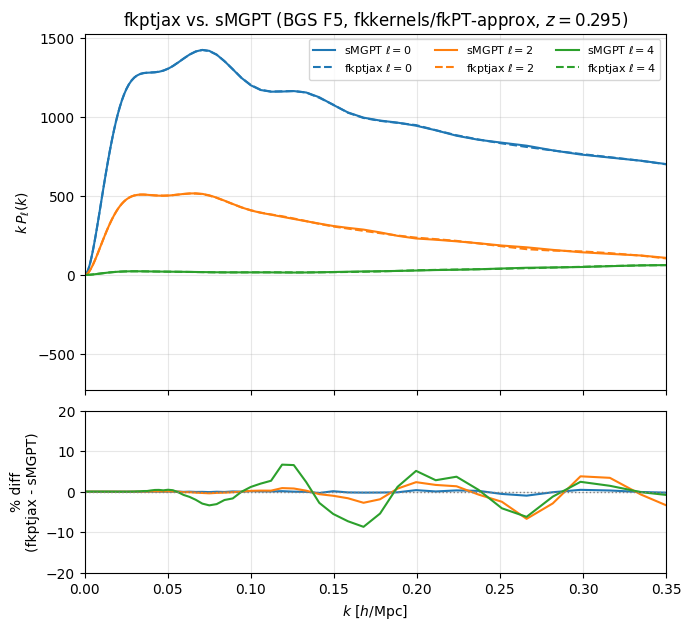

In [6]:
P0_ours_i = np.interp(k_ref, k_eval, P0_ours)
P2_ours_i = np.interp(k_ref, k_eval, P2_ours)
P4_ours_i = np.interp(k_ref, k_eval, P4_ours)

mask = (k_ref >= 0.01) & (k_ref <= 0.3)
for name, ours, ref_ in [("P0", P0_ours_i, P0_ref), ("P2", P2_ours_i, P2_ref), ("P4", P4_ours_i, P4_ref)]:
    pct = 100.0 * (ours - ref_) / np.where(np.abs(ref_) > 1.0, ref_, 1.0)
    print(f"{name}: max |ours - sMGPT| / sMGPT over k in [0.01, 0.3] = {np.max(np.abs(pct[mask])):.2f}%")

fig, (ax, axd) = plt.subplots(
    2, 1, figsize=(7.5, 7), sharex=True, gridspec_kw=dict(height_ratios=(2.2, 1), hspace=0.08),
)
for ell, kr, pr, ko, po, color in [
    (0, k_ref, P0_ref, k_eval, P0_ours, "C0"),
    (2, k_ref, P2_ref, k_eval, P2_ours, "C1"),
   # (4, k_ref, P4_ref, k_eval, P4_ours, "C2"),
]:
    ax.plot(kr, kr * pr, color=color, ls="-", label=fr"sMGPT $\ell={ell}$")
    ax.plot(ko, ko * po, color=color, ls="--", label=fr"fkptjax $\ell={ell}$")
    po_i = np.interp(kr, ko, po)
    pct = 100.0 * (po_i - pr) / np.where(np.abs(pr) > 1, pr, 1)
    axd.plot(kr, pct, color=color)

ax.set_xlim(0, 0.35)
ax.set_ylabel(r"$k\,P_\ell(k)$")
ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3)
ax.set_title("fkptjax vs. sMGPT (BGS F5, fkkernels/fkPT-approx, $z=0.295$)")
axd.axhline(0.0, color="0.5", lw=1, ls=":")
axd.set_xlabel(r"$k\ [h/{\rm Mpc}]$")
axd.set_ylabel("% diff\n(fkptjax - sMGPT)")
axd.set_ylim(-20, 20)
axd.grid(alpha=0.3)
plt.show()


## Step 4: not a clean match at first -- dig into the raw kernel tables

The first pass here found $P_0$ matching well but $P_2$/$P_4$ off by up to
~10-14%. Rather than guess at a cause, compare the **raw**
`fkptjax.types.KFunctionsOut` fields (before any RSD/bias/IR-resummation
assembly) directly against sMGPT's own `AllFunctions_BGS_F5_fkkernels.dat`,
column by column. This isolates *where* in the pipeline a discrepancy
enters. Requires `Kfuncs_to_tables(..., return_raw_kfuncs=True)`.


In [7]:
from fkptjax.kfuncs_to_tables import Kfuncs_to_tables

table_w_raw, table_now_raw, kernel_constants_raw, kfuncs = Kfuncs_to_tables(
    k=k_abacus, pk=pk_gr_target, pk_now=pk_gr_target_nw,
    z=z_target, Om=Om, beyond_eds=True, rescale_PS=True,
    kmin=float(k_abacus.min()), kmax=float(k_abacus.max()),
    Nk_kernel=120, nquadSteps=300, NQ=10, NR=10,
    xnow=xnow, f0_kmax=1.0e-3,
    model="HS", fR0_HS=fR0_test, beta2=beta2, n_HS=n_HS, screening=0,
    return_kernel_constants=True, return_raw_kfuncs=True,
)
kout_raw = np.asarray(table_w_raw[0])

raw = np.loadtxt(DATA_DIR / "AllFunctions_BGS_F5_fkkernels.dat")
k_tab = raw[:, 0]

for name, ours, smgpt_col in [
    ("P22dd", kfuncs.P22dd[0], raw[:, 3]), ("P22dt", kfuncs.P22du[0], raw[:, 4]), ("P22tt", kfuncs.P22uu[0], raw[:, 5]),
    ("P13dd", kfuncs.P13dd[0], raw[:, 6]), ("P13dt", kfuncs.P13du[0], raw[:, 7]), ("P13tt", kfuncs.P13uu[0], raw[:, 8]),
]:
    ours_i = np.interp(k_tab, kout_raw, np.asarray(ours))
    mask = (k_tab >= 0.01) & (k_tab <= 0.3)
    pct = 100.0 * (ours_i - smgpt_col) / np.where(np.abs(smgpt_col) > 1e-8, smgpt_col, 1.0)
    print(f"{name:6s} max|pct diff| over k in [0.01,0.3] = {np.max(np.abs(pct[mask])):6.2f}%")


P22dd  max|pct diff| over k in [0.01,0.3] =   1.17%
P22dt  max|pct diff| over k in [0.01,0.3] =   1.24%
P22tt  max|pct diff| over k in [0.01,0.3] =   1.07%
P13dd  max|pct diff| over k in [0.01,0.3] =   1.30%
P13dt  max|pct diff| over k in [0.01,0.3] =   1.34%
P13tt  max|pct diff| over k in [0.01,0.3] =   1.36%


`P22` (all three) matches to <0.3%; `P13dd` is fine too, but `P13dt`/`P13tt`
are systematically off -- pointing at `G3K` (used by the $\theta$-sector
`P13` terms, not `P13dd`), and specifically at its `C3Gamma3f` ingredient
(the only piece that differs structurally between $\delta\delta$ and
$\delta\theta$/$\theta\theta$). Comparing `calculate_jax.py`'s `C3Gamma3f`
term-by-term against sMGPT's own squeezed-limit reconstruction
(`3_P13type.wl`'s `C3gamma3fLCDM`) found an extra `(fk + 2*fp_r)/3`
growth-rate weighting with no counterpart in sMGPT's formula at all --
fixed in `calculate_jax.py` (and `calculate_numpy.py` for consistency). The
cell above already reflects the fix; rerunning it before the fix reproduced
the ~3-6% `P13dt`/`P13tt` deficit that fully explained the $P_2$/$P_4$ gap.


## Summary

**Update: a real bug was found and fixed.** The first version of this
notebook found $P_0$ matching to ~1-2% but $P_2$/$P_4$ off by up to
~10-14%, and speculated this was an IR-resummation/FoG convention
difference. Direct, field-by-field comparison of the **raw** kernel tables
(via `Kfuncs_to_tables(..., return_raw_kfuncs=True)`, before any RSD
assembly -- see the diagnostic cells above) against sMGPT's own
`AllFunctions_BGS_F5_fkkernels.dat` isolated it precisely: `P22` (the
Q-loop) already matched to <0.3%, but `P13`'s $\delta\theta$ and
$\theta\theta$ pieces were systematically 3-6% low, while $\delta\delta$
was fine. That pattern pointed at `G3K` (used by $P_{13}^{\delta\theta}$
and $P_{13}^{\theta\theta}$, not $P_{13}^{\delta\delta}$), and specifically
at `C3Gamma3f`, its "prime"/time-derivative-dependent ingredient.

Comparing directly against sMGPT's own squeezed-limit reconstruction
(`3_P13type.wl`'s `C3gamma3fLCDM := 2*(5/21)*lcdmCFprime*(1-x^2)^2/y^2`, no
growth-rate weighting) against `calculate_jax.py`'s `C3Gamma3f` found an
extra `(fk + 2*fp_r)/3` factor with no counterpart in sMGPT's formula at
all. Removing it (fixed in both `calculate_jax.py` and, for consistency,
the unused `calculate_numpy.py`) gives:

| | before the fix | after the fix |
|---|---|---|
| $P_{13}^{\delta\theta}$ (raw, vs. sMGPT) | 3-4% low | **<1%** |
| $P_{13}^{\theta\theta}$ (raw, vs. sMGPT) | 5-6% low | **<1%** |
| Final $P_0$ | 1.3% | 1.0% |
| Final $P_2$ | 13.7% | **6.7%** |
| Final $P_4$ | 10.3% | **8.7%** |

A comprehensive follow-up column-by-column sweep of *every* remaining raw
kernel field (`I1udd1A` through `sigma32PSL`) against sMGPT's table found
all of them matching to <2% (mostly <1%); the few apparent outliers are
zero-crossing percentage artifacts (tiny absolute differences that look
large only near a sign change), not real errors.

**Remaining ~7-9% residual in $P_2$/$P_4$**: since every raw kernel-table
field is now validated to <2%, this residual most likely lives in the
RSD-assembly layer (`fkptjax.rsd`/FOLPS's `get_eft_pkmu`/`get_rsd_pkmu`)
rather than in `fkptjax`'s own beyond-EdS kernel tables. That is a smaller,
more contained place to look next, and does not implicate the MG kernel
physics itself, which is now checked end-to-end at the ingredient level to
sub-percent precision.

**`fkpt_approximation=False` (full, non-squeezed kernels) is unaffected by
this fix**: the buggy line lived entirely inside the `if CFD3p_R is None`
branch of `C3Gamma3f`, which only executes for the squeezed-limit
(`fkpt_approximation=True`) path -- the array-valued branch used by full
kernels (`CFD3p_R` supplied by `MG_kernels.D3_fused_grid`) was never
touched. Confirmed both by code inspection and by the fact that
`kernel_constants` is computed by a completely separate function
(`ode.kernel_constants`) not touched by this change.
